# Customer Churn Prediction
Complete ML pipeline.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay,roc_curve,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib

df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Cleaning

In [3]:
df=df.drop(columns=['customerID'])
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df=df.dropna().drop_duplicates()
df['Churn']=df['Churn'].map({'Yes':1,'No':0})
cat=df.select_dtypes(include='object').columns
for c in cat:
    df[c]=LabelEncoder().fit_transform(df[c])
print(df.shape)
df.info()

(7010, 20)
<class 'pandas.core.frame.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   int64  
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   int64  
 3   Dependents        7010 non-null   int64  
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   int64  
 6   MultipleLines     7010 non-null   int64  
 7   InternetService   7010 non-null   int64  
 8   OnlineSecurity    7010 non-null   int64  
 9   OnlineBackup      7010 non-null   int64  
 10  DeviceProtection  7010 non-null   int64  
 11  TechSupport       7010 non-null   int64  
 12  StreamingTV       7010 non-null   int64  
 13  StreamingMovies   7010 non-null   int64  
 14  Contract          7010 non-null   int64  
 15  PaperlessBilling  7010 non-null   int64  
 16  PaymentMethod     7010 non-null   in

## EDA

            gender  SeniorCitizen      Partner   Dependents       tenure  \
count  7010.000000    7010.000000  7010.000000  7010.000000  7010.000000   
mean      0.504280       0.162767     0.484023     0.299429    32.520399   
std       0.500017       0.369180     0.499780     0.458041    24.520441   
min       0.000000       0.000000     0.000000     0.000000     1.000000   
25%       0.000000       0.000000     0.000000     0.000000     9.000000   
50%       1.000000       0.000000     0.000000     0.000000    29.000000   
75%       1.000000       0.000000     1.000000     1.000000    56.000000   
max       1.000000       1.000000     1.000000     1.000000    72.000000   

       PhoneService  MultipleLines  InternetService  OnlineSecurity  \
count   7010.000000    7010.000000      7010.000000     7010.000000   
mean       0.902996       0.943509         0.870471        0.789729   
std        0.295985       0.948648         0.736546        0.860846   
min        0.000000       0.000

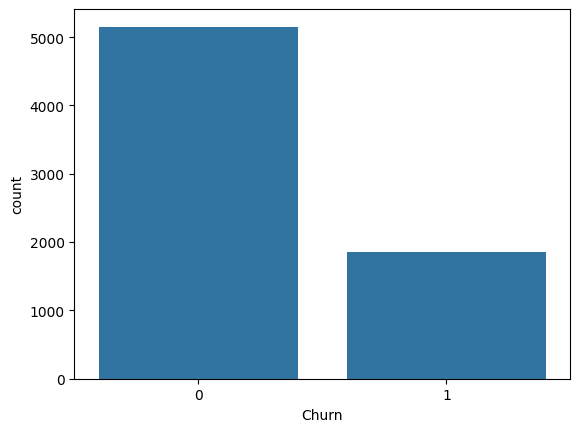

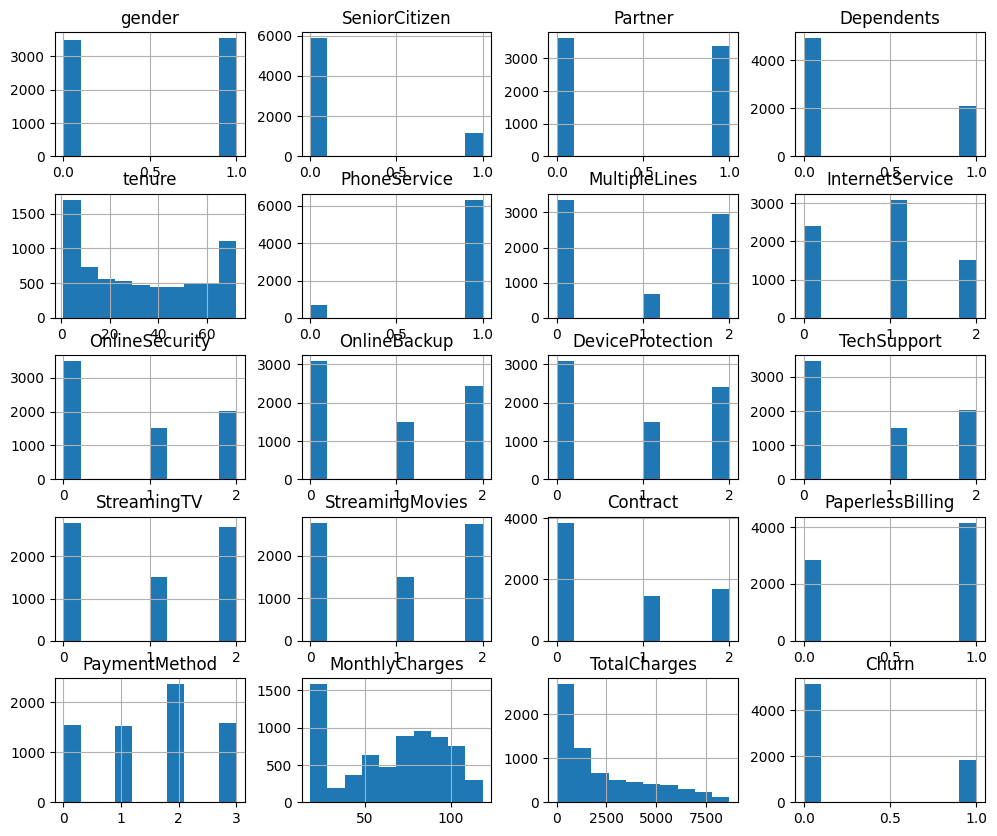

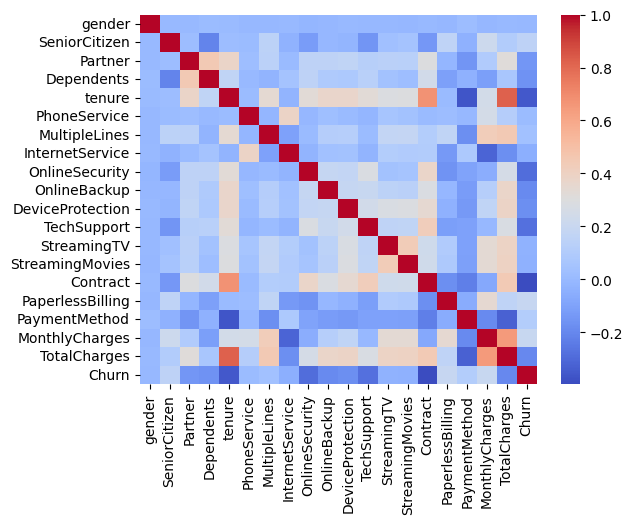

In [5]:
print(df.describe())
sns.countplot(x='Churn',data=df);plt.show()
df.hist(figsize=(12,10));plt.show()

sns.heatmap(df.corr(),cmap='coolwarm')
plt.show()

## Split

In [6]:
X=df.drop('Churn',axis=1)
y=df['Churn']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
sc=StandardScaler()
X_train_s=sc.fit_transform(X_train)
X_test_s=sc.transform(X_test)

## Models

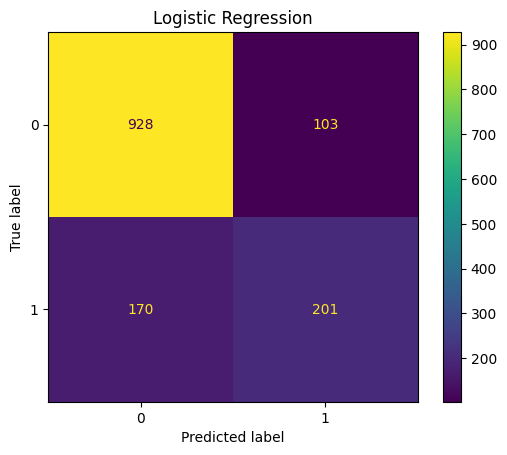

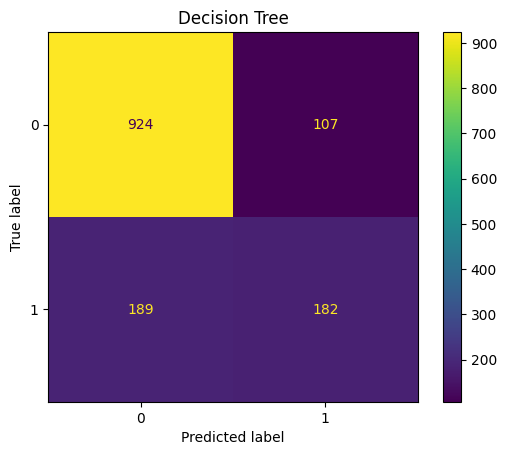

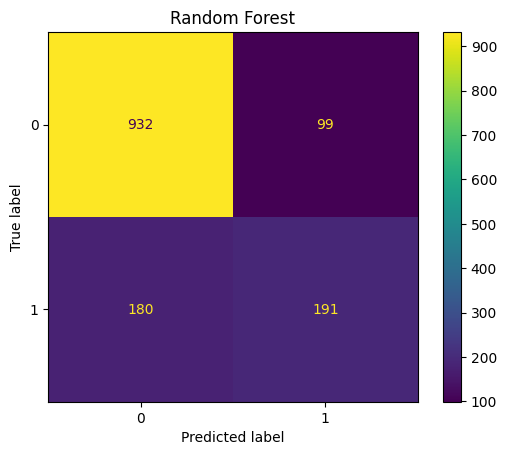

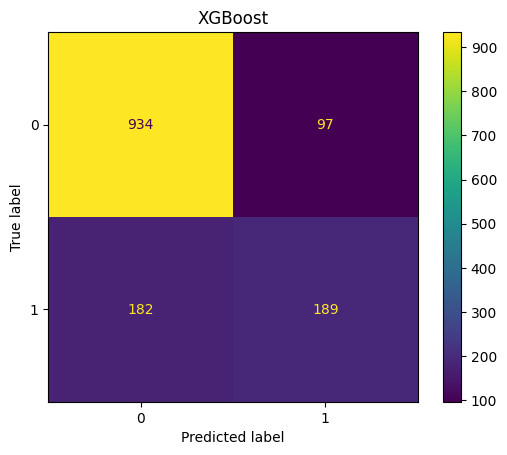

                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
0  Logistic Regression  0.805278   0.661184  0.541779  0.595556  0.847313
2        Random Forest  0.800999   0.658621  0.514825  0.577912  0.843318
3              XGBoost  0.800999   0.660839  0.509434  0.575342  0.841590
1        Decision Tree  0.788873   0.629758  0.490566  0.551515  0.825343


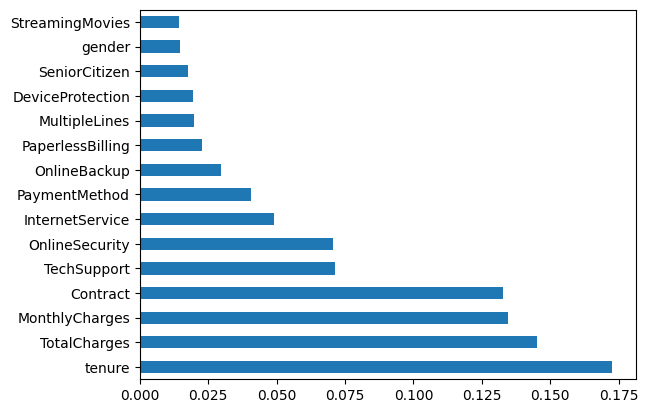

In [8]:
results=[]
models={
'Logistic Regression':(LogisticRegression(max_iter=1000),X_train_s,X_test_s),
'Decision Tree':(DecisionTreeClassifier(random_state=42),X_train,X_test),
'Random Forest':(RandomForestClassifier(random_state=42),X_train,X_test),
'XGBoost':(XGBClassifier(eval_metric='logloss',random_state=42),X_train,X_test)
}
params={
'Decision Tree':{'max_depth':[3,5,10,None],'min_samples_split':[2,5,10]},
'Random Forest':{'n_estimators':[100,200],'max_depth':[None,10],'min_samples_split':[2,5]},
'XGBoost':{'n_estimators':[100,200],'max_depth':[3,5],'learning_rate':[0.05,0.1]}
}
trained={}
for name,(m,tr,te) in models.items():
    if name in params:
        g=GridSearchCV(m,params[name],cv=5,scoring='f1',n_jobs=-1)
        g.fit(tr,y_train)
        m=g.best_estimator_
    else:
        m.fit(tr,y_train)
    if name in params: pass
    y_pred=m.predict(te)
    y_prob=m.predict_proba(te)[:,1]
    results.append([name,accuracy_score(y_test,y_pred),precision_score(y_test,y_pred),recall_score(y_test,y_pred),f1_score(y_test,y_pred),roc_auc_score(y_test,y_prob)])
    trained[name]=m
    ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred)).plot()
    plt.title(name)
    plt.show()


res=pd.DataFrame(results,columns=['Model','Accuracy','Precision','Recall','F1','ROC_AUC'])
print(res.sort_values('F1',ascending=False))
best=res.sort_values('F1',ascending=False).iloc[0]['Model']
joblib.dump(trained[best],'best_model.pkl')
if 'Random Forest' in trained:
    fi=pd.Series(trained['Random Forest'].feature_importances_,index=X.columns).sort_values(ascending=False)
    fi.head(15).plot(kind='barh')
    plt.show()
